In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Customer_Purchase_Prediction_5000_Members_30_Blank_15_NaN_30_Duplicates.csv")

print("Dataset Shape:", df.shape)
display(df)

Dataset Shape: (5000, 13)


,Customer_ID,Age,Gender,Annual_Income,Customer_Segment,Previous_Purchases,Website_Visits,Pages_Viewed,Time_on_Website_Min,Emails_Opened,Cart_Additions,Days_Since_Last_Purchase,Purchase
0,C0001,56.0,Male,66057.0,New,12.0,1.0,15.0,10.0,5.0,5.0,59.0,1
1,C0002,46.0,Female,32537.0,Regular,8.0,14.0,10.0,4.0,7.0,5.0,155.0,0
2,C0003,32.0,Female,42419.0,Regular,0.0,11.0,4.0,54.0,9.0,5.0,58.0,1
3,C0004,60.0,Female,62578.0,New,10.0,7.0,8.0,4.0,1.0,6.0,61.0,1
4,C0005,25.0,Male,94991.0,New,5.0,2.0,6.0,6.0,8.0,2.0,118.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,C0026,39.0,Male,136908.0,Regular,15.0,20.0,6.0,49.0,6.0,0.0,172.0,0
4996,C0027,42.0,Male,134921.0,New,14.0,6.0,1.0,21.0,7.0,4.0,134.0,1
4997,C0028,44.0,Female,119096.0,New,4.0,9.0,9.0,8.0,10.0,6.0,116.0,0
4998,C0029,59.0,Female,99731.0,New,15.0,5.0,9.0,28.0,3.0,6.0,101.0,1


## 1. Dataset Description
The dataset contains 5,000 customer records and 13 columns. It includes customer demographic information, annual income, purchasing history, and website activity.

The target variable is `Purchase`, where 0 represents no purchase and 1 represents a purchase.

The dataset contains both numerical and categorical features. `Customer_ID` is a unique identifier and will be removed prior to model training.

In [3]:
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               5000 non-null   object 
 1   Age                       4995 non-null   float64
 2   Gender                    4995 non-null   object 
 3   Annual_Income             4995 non-null   float64
 4   Customer_Segment          4996 non-null   object 
 5   Previous_Purchases        4996 non-null   float64
 6   Website_Visits            4996 non-null   float64
 7   Pages_Viewed              4995 non-null   float64
 8   Time_on_Website_Min       4996 non-null   float64
 9   Emails_Opened             4997 non-null   float64
 10  Cart_Additions            4997 non-null   float64
 11  Days_Since_Last_Purchase  4997 non-null   float64
 12  Purchase                  5000 non-null   int64  
dtypes: float64(9), int64(1), object(3)
memory u

## 2. Initial Data Quality Check
The dataset contains 5,000 records and 13 columns. The `df.info()` output shows both numerical and categorical features with some missing values. The initial quality inspection identifies 30 duplicate records and 45 missing values across the columns. These data quality issues will be addressed during preprocessing.

In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 30


In [5]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:
Customer_ID                 0
Age                         5
Gender                      5
Annual_Income               5
Customer_Segment            4
Previous_Purchases          4
Website_Visits              4
Pages_Viewed                5
Time_on_Website_Min         4
Emails_Opened               3
Cart_Additions              3
Days_Since_Last_Purchase    3
Purchase                    0
dtype: int64

Total Missing Values: 45


In [6]:
print("Purchase Class Distribution:")
print(df["Purchase"].value_counts())

print("\nPurchase Percentage:")
print(df["Purchase"].value_counts(normalize=True) * 100)

Purchase Class Distribution:
Purchase
0    2921
1    2079
Name: count, dtype: int64

Purchase Percentage:
Purchase
0    58.42
1    41.58
Name: proportion, dtype: float64


In [7]:
print("Shape Before Removing Duplicates:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:", df.shape)
print("Duplicate Rows After Removal:", df.duplicated().sum())

Shape Before Removing Duplicates: (5000, 13)
Duplicate Rows: 30

Shape After Removing Duplicates: (4970, 13)
Duplicate Rows After Removal: 0


In [8]:
print("Missing Values Before Treatment:")
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

Missing Values Before Treatment:
Customer_ID                 0
Age                         5
Gender                      5
Annual_Income               5
Customer_Segment            4
Previous_Purchases          4
Website_Visits              4
Pages_Viewed                5
Time_on_Website_Min         4
Emails_Opened               3
Cart_Additions              3
Days_Since_Last_Purchase    3
Purchase                    0
dtype: int64

Total Missing Values: 45


In [9]:
numerical_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Age', 'Annual_Income', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase', 'Purchase']

Categorical Columns:
['Customer_ID', 'Gender', 'Customer_Segment']


In [10]:
df = df.drop("Customer_ID", axis=1)

print("Shape After Removing Customer_ID:", df.shape)
print("\nRemaining Columns:")
print(df.columns.tolist())

Shape After Removing Customer_ID: (4970, 12)

Remaining Columns:
['Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase', 'Purchase']


In [11]:
numerical_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

# Remove target from numerical feature list
numerical_features = [col for col in numerical_columns if col != "Purchase"]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['Age', 'Annual_Income', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase']

Categorical Features:
['Gender', 'Customer_Segment']


In [12]:
# Handle missing values in numerical features

for column in numerical_features:
    if df[column].isnull().sum() > 0:
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)
        print(column, "-> Median used:", median_value)


# Handle missing values in categorical features

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(mode_value)
        print(column, "-> Mode used:", mode_value)

Age -> Median used: 39.0
Annual_Income -> Median used: 86134.0
Previous_Purchases -> Median used: 7.0
Website_Visits -> Median used: 11.0
Pages_Viewed -> Median used: 8.0
Time_on_Website_Min -> Median used: 31.0
Emails_Opened -> Median used: 5.0
Cart_Additions -> Median used: 4.0
Days_Since_Last_Purchase -> Median used: 92.0
Gender -> Mode used: Female
Customer_Segment -> Mode used: Regular


In [13]:
print("Missing Values After Treatment:")
print(df.isnull().sum())

print("\nTotal Missing Values After Treatment:",
      df.isnull().sum().sum())

Missing Values After Treatment:
Age                         0
Gender                      0
Annual_Income               0
Customer_Segment            0
Previous_Purchases          0
Website_Visits              0
Pages_Viewed                0
Time_on_Website_Min         0
Emails_Opened               0
Cart_Additions              0
Days_Since_Last_Purchase    0
Purchase                    0
dtype: int64

Total Missing Values After Treatment: 0


In [14]:
print("Descriptive Statistics")
print("=" * 50)

display(df.describe())

Descriptive Statistics


,Age,Annual_Income,Previous_Purchases,Website_Visits,Pages_Viewed,Time_on_Website_Min,Emails_Opened,Cart_Additions,Days_Since_Last_Purchase,Purchase
count,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000,4970.000000
mean,39.112072,85316.454930,7.507445,10.547485,8.076660,30.933602,5.057746,3.522133,90.765996,0.415493
std,12.271109,37617.185536,4.652553,5.769632,4.304934,17.332577,3.145829,2.298777,52.607832,0.492856
min,18.000000,20002.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,29.000000,52628.500000,3.000000,6.000000,4.000000,16.000000,2.000000,2.000000,45.000000,0.000000
50%,39.000000,86134.000000,7.000000,11.000000,8.000000,31.000000,5.000000,4.000000,92.000000,0.000000
75%,50.000000,117900.750000,12.000000,16.000000,12.000000,46.000000,8.000000,6.000000,136.000000,1.000000
max,60.000000,150000.000000,15.000000,20.000000,15.000000,60.000000,10.000000,7.000000,180.000000,1.000000


In [15]:
print("Categorical Data Summary")
print("=" * 50)

display(df.describe(include='object'))

Categorical Data Summary


,Gender,Customer_Segment
count,4970,4970
unique,2,3
top,Female,Regular
freq,2510,2235


## 3. EDA

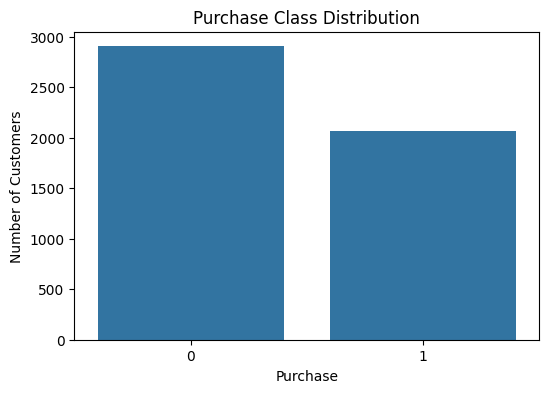

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Purchase")

plt.title("Purchase Class Distribution")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")

plt.show()

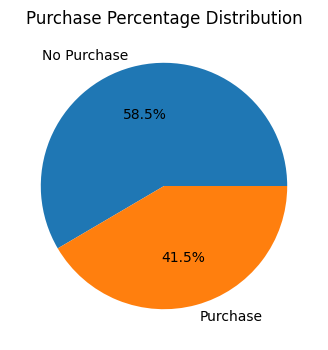

In [17]:
purchase_counts = df["Purchase"].value_counts()

plt.figure(figsize=(6, 4))

plt.pie(
    purchase_counts,
    labels=["No Purchase", "Purchase"],
    autopct="%1.1f%%"
)

plt.title("Purchase Percentage Distribution")
plt.show()

## Observation
The purchase class distribution shows that 58.4% of the customers did not make a purchase, while 41.6% made a purchase (2,921 vs 2,079). Therefore, the target variable exhibits a moderate class imbalance.

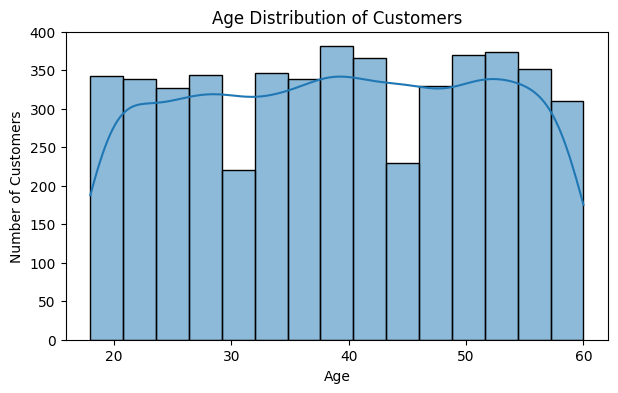

In [18]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Age", bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

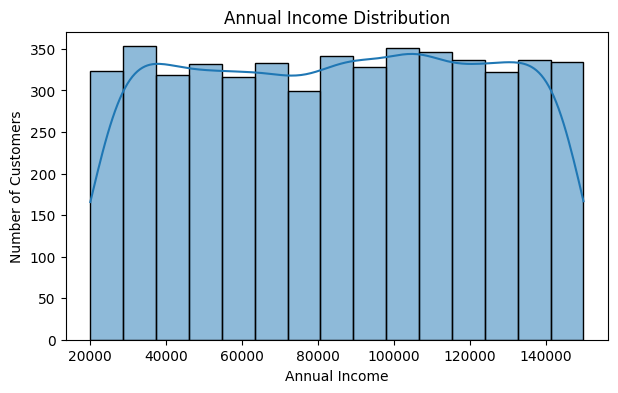

In [19]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Annual_Income", bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

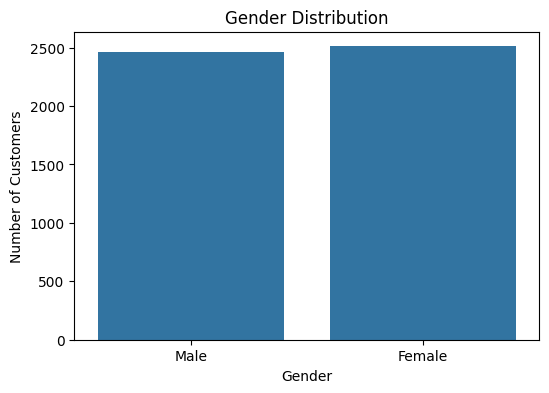

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

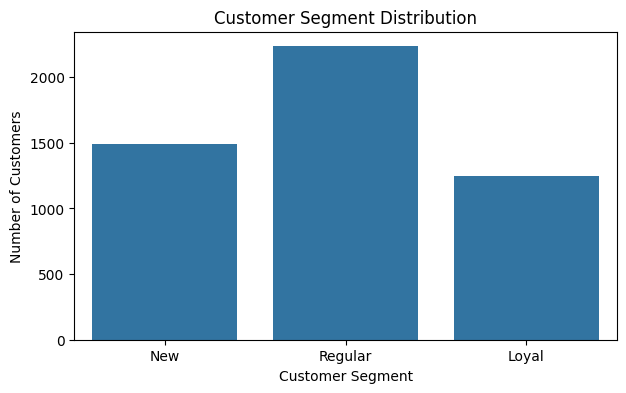

In [21]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="Customer_Segment")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

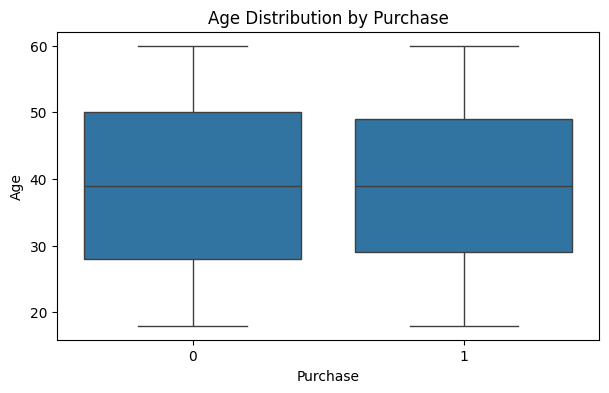

In [22]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Age")

plt.title("Age Distribution by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Age")

plt.show()

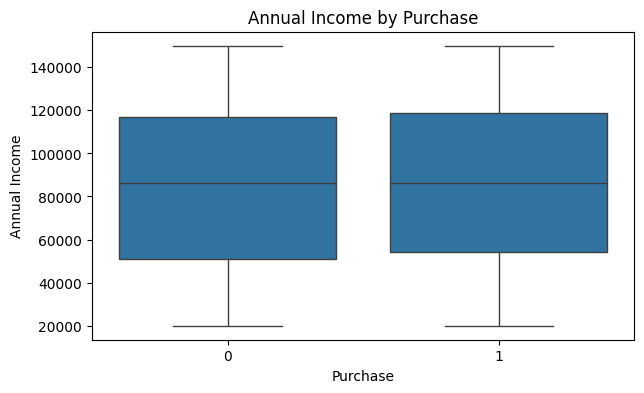

In [23]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Annual_Income")

plt.title("Annual Income by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Annual Income")

plt.show()

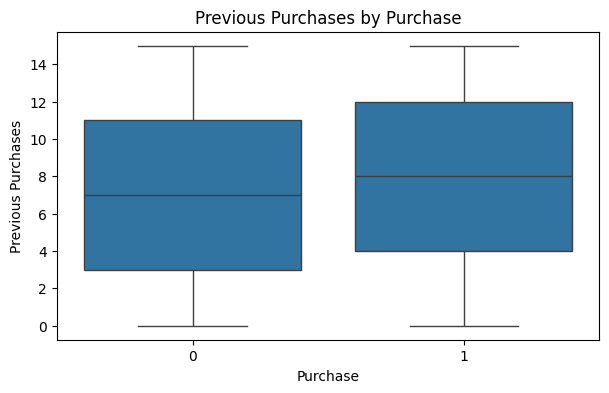

In [24]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Previous_Purchases")

plt.title("Previous Purchases by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Previous Purchases")

plt.show()

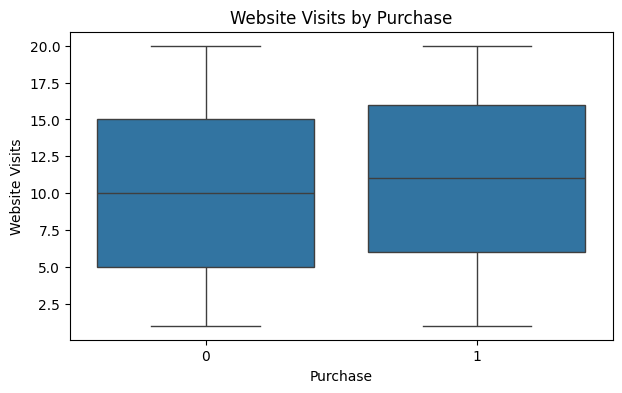

In [25]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Website_Visits")

plt.title("Website Visits by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Website Visits")

plt.show()

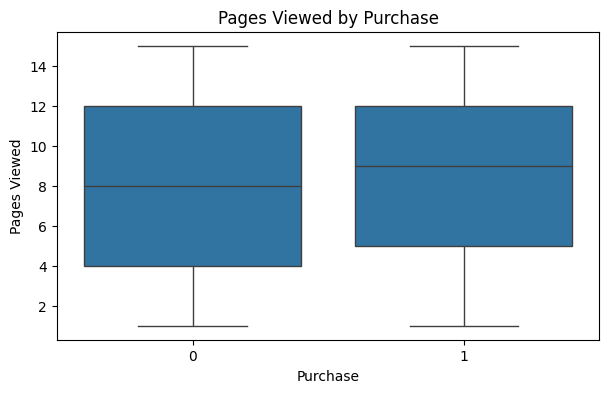

In [26]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Pages_Viewed")

plt.title("Pages Viewed by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Pages Viewed")

plt.show()

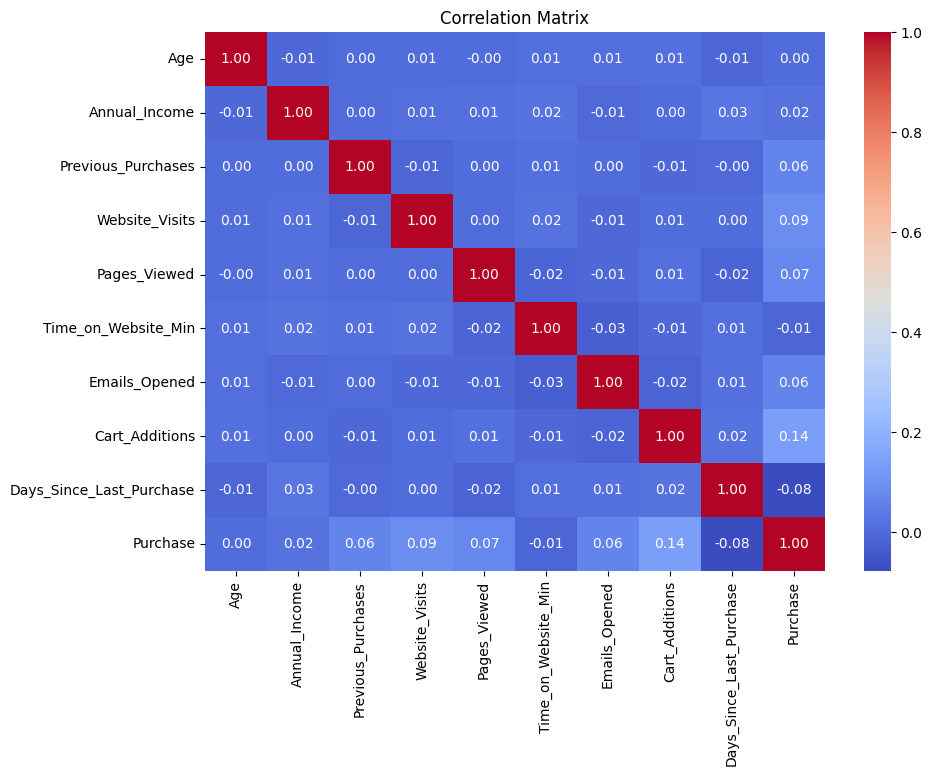

In [27]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

The correlation matrix was used to examine the relationships between numerical features and the target variable `Purchase`. The correlations with `Purchase` are relatively weak, indicating that no single numerical feature has a strong linear relationship with the target.

In [28]:
print("Features used for modelling:")
print(df.drop("Purchase", axis=1).columns.tolist())

print("\nTarget variable:")
print("Purchase")

Features used for modelling:
['Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase']

Target variable:
Purchase


## 4. Unsupervised Learning

Unsupervised learning was performed to identify natural customer groups based on demographic and behavioural characteristics. K-Means Clustering and Hierarchical Clustering were applied without using the target variable `Purchase`.

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

cluster_df = pd.read_csv("Customer_Purchase_Prediction_5000_Members_30_Blank_15_NaN_30_Duplicates.csv")

cluster_df = cluster_df.drop_duplicates()

numeric_features = [
    "Age",
    "Annual_Income",
    "Previous_Purchases",
    "Website_Visits",
    "Pages_Viewed",
    "Time_on_Website_Min",
    "Emails_Opened",
    "Cart_Additions",
    "Days_Since_Last_Purchase"
]

X_cluster = cluster_df[numeric_features]

imputer = SimpleImputer(strategy="median")
X_cluster = imputer.fit_transform(X_cluster)

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Clustering data shape:", X_cluster_scaled.shape)

Clustering data shape: (4970, 9)


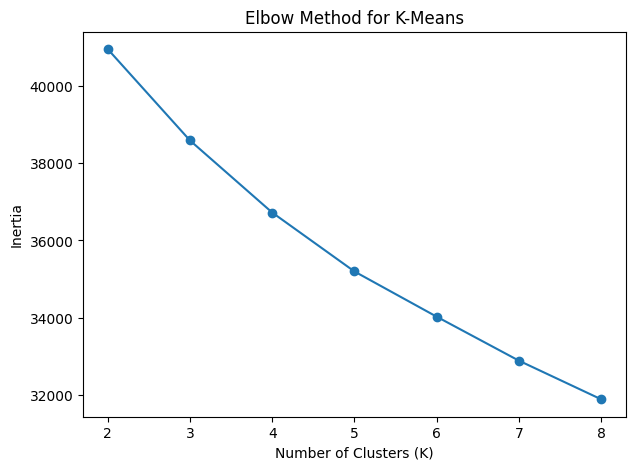

In [60]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

cluster_df["Customer_Cluster"] = cluster_labels

print(cluster_df["Customer_Cluster"].value_counts())

Customer_Cluster
1    1820
2    1593
0    1557
Name: count, dtype: int64


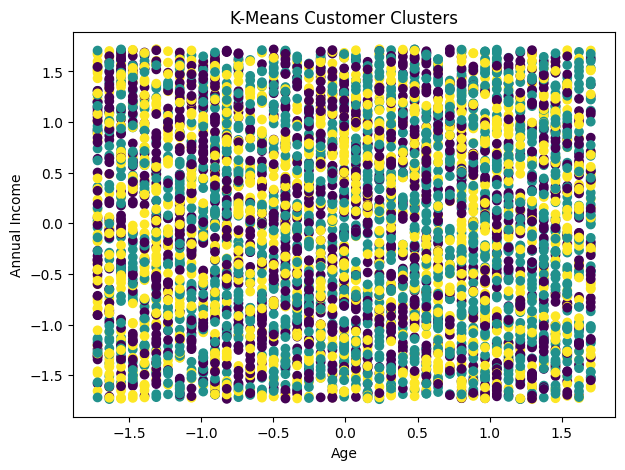

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_cluster_scaled[:, 0],
    X_cluster_scaled[:, 1],
    c=cluster_labels
)

plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("K-Means Customer Clusters")
plt.show()

In [33]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

# Silhouette Score for K-Means (k=3)
sil_score = silhouette_score(X_cluster_scaled, cluster_labels)
print("K-Means (k=3) Silhouette Score:", round(sil_score, 4))

# DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_cluster_scaled)
print("DBSCAN Detected Clusters:", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("DBSCAN Detected Outliers (noise):", list(db_labels).count(-1))

K-Means (k=3) Silhouette Score: 0.0737
DBSCAN Detected Clusters: 32
DBSCAN Detected Outliers (noise): 1353


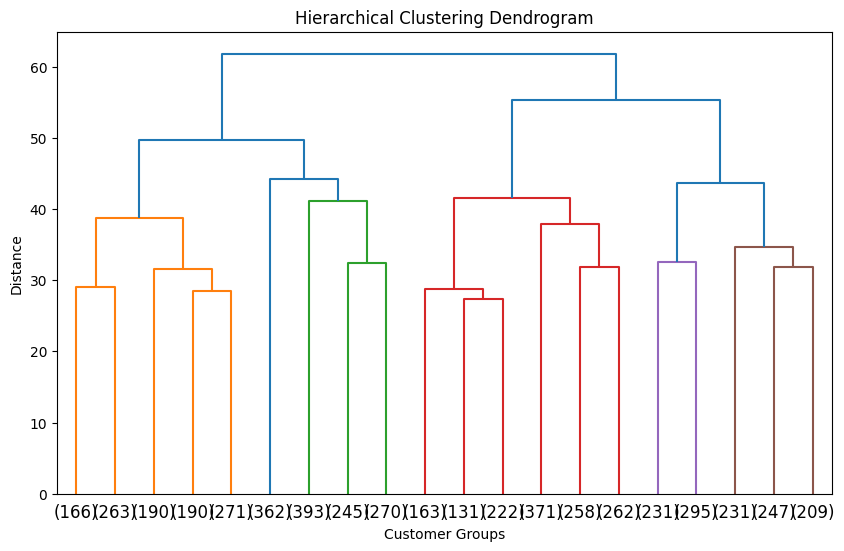

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_cluster_scaled, method="ward")

plt.figure(figsize=(10, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)

plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

## 5. Model Preparation and Preprocessing

The cleaned dataset was divided into training and testing sets using an 80:20 stratified split. Numerical features were standardized and categorical features were one-hot encoded using a preprocessing pipeline.

The preprocessing pipeline is fitted as part of the training process so that information from the test dataset is not used during preprocessing, helping to prevent data leakage.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load the original raw dataset again
model_df = pd.read_csv("Customer_Purchase_Prediction_5000_Members_30_Blank_15_NaN_30_Duplicates.csv")

# Remove duplicate rows
model_df = model_df.drop_duplicates()

# Remove Customer_ID
model_df = model_df.drop("Customer_ID", axis=1)

# Separate features and target
X = model_df.drop("Purchase", axis=1)
y = model_df["Purchase"]

print("Dataset shape for modelling:", model_df.shape)
print("Features:", X.columns.tolist())
print("Target: Purchase")

Dataset shape for modelling: (4970, 12)
Features: ['Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase']
Target: Purchase


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3976
Testing samples: 994


In [37]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Previous_Purchases",
    "Website_Visits",
    "Pages_Viewed",
    "Time_on_Website_Min",
    "Emails_Opened",
    "Cart_Additions",
    "Days_Since_Last_Purchase"
]

categorical_features = [
    "Gender",
    "Customer_Segment"
]

In [38]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 6. Logistic Regression

Logistic Regression was implemented as a baseline classification model for predicting customer purchase behaviour.

In [39]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression Results")
print("=" * 40)
print("Accuracy :", round(accuracy_log, 4))
print("Precision:", round(precision_log, 4))
print("Recall   :", round(recall_log, 4))
print("F1-Score :", round(f1_log, 4))

Logistic Regression Results
Accuracy : 0.6177
Precision: 0.5702
Recall   : 0.3245
F1-Score : 0.4136


In [41]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.63      0.83      0.72       581
           1       0.57      0.32      0.41       413

    accuracy                           0.62       994
   macro avg       0.60      0.58      0.56       994
weighted avg       0.61      0.62      0.59       994



Logistic Regression Confusion Matrix:
[[480 101]
 [279 134]]


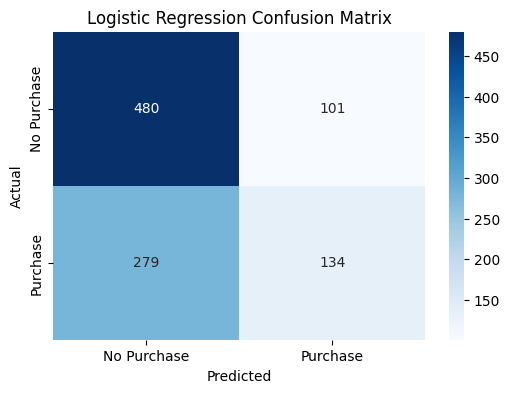

In [42]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

print("Logistic Regression Confusion Matrix:")
print(cm_log)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probability of the positive class
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression ROC-AUC:", round(roc_auc_log, 4))

Logistic Regression ROC-AUC: 0.6351


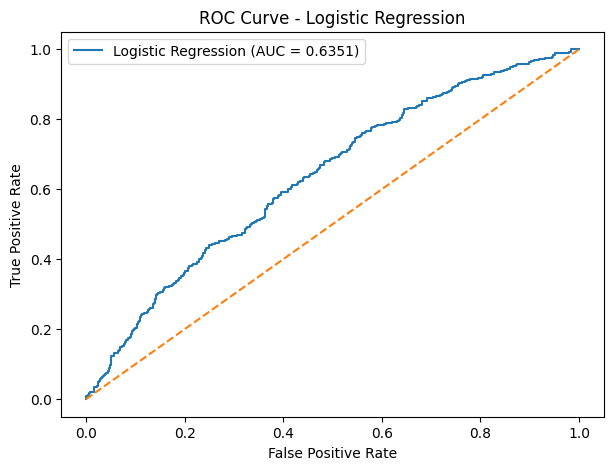

In [44]:
plt.figure(figsize=(7, 5))

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_log:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

## 7. Random Forest

Random Forest was implemented as a second classification model to compare its performance with Logistic Regression.

In [45]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [46]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("=" * 40)
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))

Random Forest Results
Accuracy : 0.5795
Precision: 0.489
Recall   : 0.2688
F1-Score : 0.3469


In [47]:
print("Random Forest Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.61      0.80      0.69       581
           1       0.49      0.27      0.35       413

    accuracy                           0.58       994
   macro avg       0.55      0.53      0.52       994
weighted avg       0.56      0.58      0.55       994



Random Forest Confusion Matrix:
[[465 116]
 [302 111]]


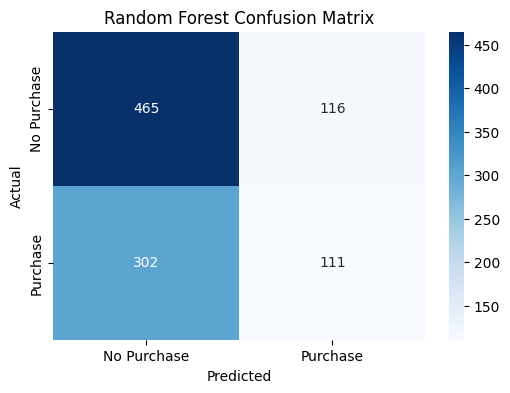

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [49]:
# Probability of the positive class
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", round(roc_auc_rf, 4))

Random Forest ROC-AUC: 0.5775


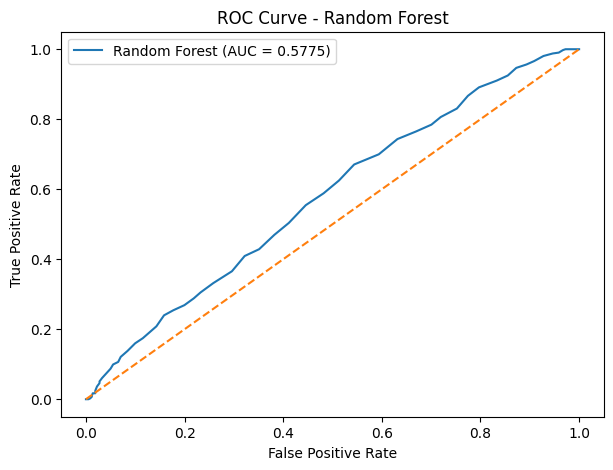

In [50]:
plt.figure(figsize=(7, 5))

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [51]:
# Get feature names after preprocessing
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importance
importances = random_forest_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,num__Annual_Income,0.133246
8,num__Days_Since_Last_Purchase,0.130611
5,num__Time_on_Website_Min,0.115688
0,num__Age,0.112940
3,num__Website_Visits,0.098180
2,num__Previous_Purchases,0.091705
4,num__Pages_Viewed,0.091118
6,num__Emails_Opened,0.080205
7,num__Cart_Additions,0.072857
13,cat__Customer_Segment_Regular,0.015738


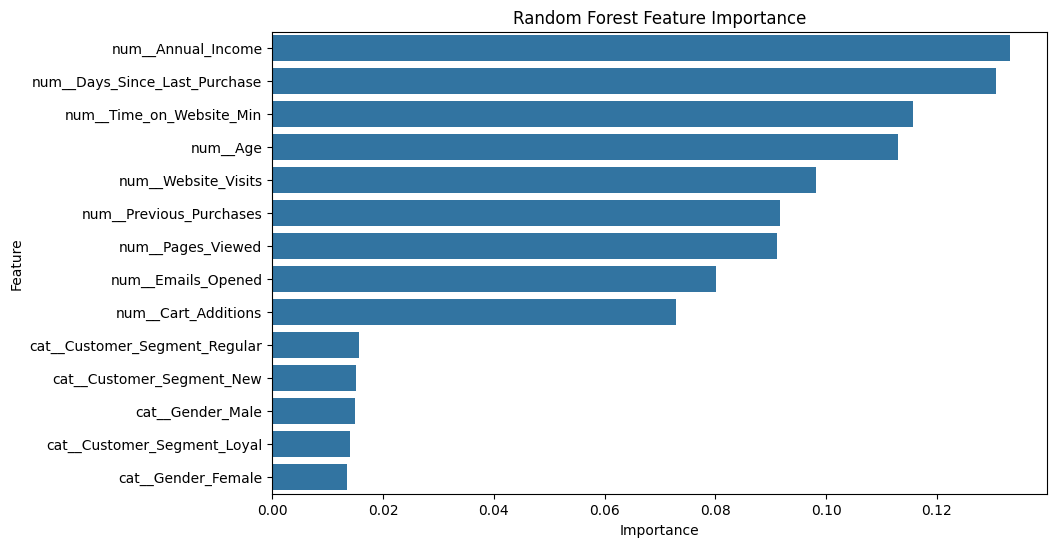

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Random Forest Feature Importance

The feature-importance results show that `Days_Since_Last_Purchase`, `Annual_Income`, `Time_on_Website_Min`, `Website_Visits`, and `Age` have relatively higher importance in the fitted Random Forest model. These values indicate the contribution of each feature to the model's predictions and do not imply a causal relationship.

## 8. Hyperparameter Tuning

Grid Search with 5-fold cross-validation was used to evaluate different Random Forest hyperparameter combinations. The parameters considered include the number of trees, maximum tree depth, and minimum samples required for splitting.

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:",
      round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

Best Cross-Validation Accuracy: 0.6089


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_rf_model = grid_search.best_estimator_
# Tuned Random Forest predictions
y_pred_tuned = best_rf_model.predict(X_test)
y_prob_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Tuned Random Forest metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Random Forest")
print("Accuracy:", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall:", round(recall_tuned, 4))
print("F1-Score:", round(f1_tuned, 4))
print("ROC-AUC:", round(roc_auc_tuned, 4))

Tuned Random Forest
Accuracy: 0.5986
Precision: 0.534
Recall: 0.2663
F1-Score: 0.3554
ROC-AUC: 0.6046


In [55]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_rf,
        accuracy_tuned
    ],
    "Precision": [
        precision_log,
        precision_rf,
        precision_tuned
    ],
    "Recall": [
        recall_log,
        recall_rf,
        recall_tuned
    ],
    "F1-Score": [
        f1_log,
        f1_rf,
        f1_tuned
    ],
    "ROC-AUC": [
        roc_auc_log,
        roc_auc_rf,
        roc_auc_tuned
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6177,0.5702,0.3245,0.4136,0.6351
1,Random Forest,0.5795,0.4890,0.2688,0.3469,0.5775
2,Tuned Random Forest,0.5986,0.5340,0.2663,0.3554,0.6046


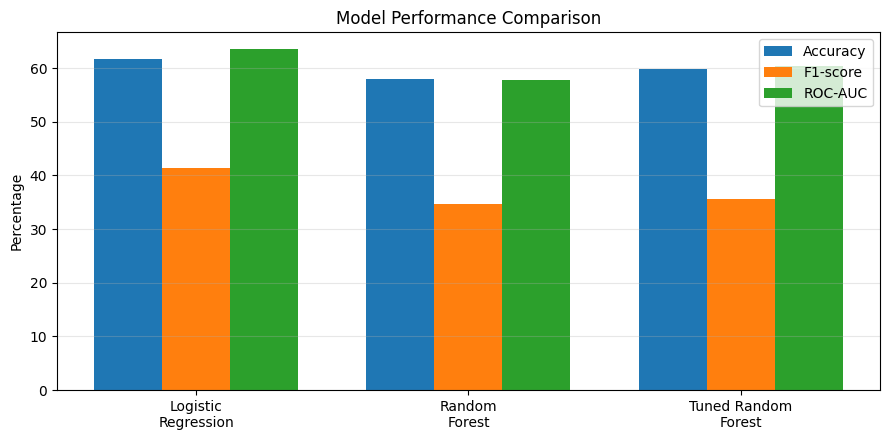

In [56]:
metrics = ['Accuracy', 'F1-score', 'ROC-AUC']
models = comparison['Model']
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 4.5))
plt.bar(x - width, comparison['Accuracy'] * 100, width, label='Accuracy')
plt.bar(x, comparison['F1-Score'] * 100, width, label='F1-score')
plt.bar(x + width, comparison['ROC-AUC'] * 100, width, label='ROC-AUC')

plt.title('Model Performance Comparison')
plt.ylabel('Percentage')
plt.xticks(x, ['Logistic\nRegression', 'Random\nForest', 'Tuned Random\nForest'])
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Model Comparison

The three implemented models were compared using accuracy, precision, recall, F1-score, and ROC-AUC. The comparison helps evaluate their performance on the same test dataset.

## 10. Final Prediction / Demonstration

The trained Logistic Regression model is used to demonstrate prediction on a new customer record that was not included in the training or test data.

In [57]:
new_customer = pd.DataFrame({
    "Age": [35],
    "Gender": ["Male"],
    "Annual_Income": [80000],
    "Customer_Segment": ["Regular"],
    "Previous_Purchases": [5],
    "Website_Visits": [10],
    "Pages_Viewed": [6],
    "Time_on_Website_Min": [12],
    "Emails_Opened": [4],
    "Cart_Additions": [2],
    "Days_Since_Last_Purchase": [60]
})

display(new_customer)

,Age,Gender,Annual_Income,Customer_Segment,Previous_Purchases,Website_Visits,Pages_Viewed,Time_on_Website_Min,Emails_Opened,Cart_Additions,Days_Since_Last_Purchase
0,35,Male,80000,Regular,5,10,6,12,4,2,60


In [58]:
prediction = logistic_model.predict(new_customer)
probability = logistic_model.predict_proba(new_customer)[0][1]

print("Predicted Purchase:", prediction[0])
print("Purchase Probability:", round(probability, 4))

Predicted Purchase: 0
Purchase Probability: 0.3504


### 11. Results and Discussion

Three classification models were implemented and evaluated on the full 5,000-record dataset using an 80:20 stratified split (3,976 training samples, 994 test samples): Logistic Regression, Random Forest, and Tuned Random Forest.

* **Logistic Regression:** Achieved an accuracy of 61.77%, precision of 57.02%, recall of 32.45%, F1-score of 41.36%, and an ROC-AUC of 0.6351.
* **Random Forest (Baseline):** Achieved an accuracy of 57.95%, precision of 48.90%, recall of 26.88%, F1-score of 34.69%, and an ROC-AUC of 0.5775.
* **Tuned Random Forest:** Through 5-fold cross-validation grid search (`max_depth=10`, `min_samples_split=5`, `n_estimators=50`), achieved a best CV accuracy of 60.89%. On the test set, it reached an accuracy of 59.86%, precision of 53.40%, recall of 26.63%, F1-score of 35.54%, and an ROC-AUC of 0.6046.

### Key Insights:
1. **Model Performance:** Logistic Regression yielded the highest overall test accuracy (61.77%) and ROC-AUC (0.6351), outperforming both the default and tuned Random Forest models.
2. **Class Imbalance & Recall:** Across all three models, recall on the positive class (`Purchase = 1`) remains between 26% and 33%, indicating that models are more conservative and frequently predict non-purchases.
3. **Feature Importance:** The Random Forest analysis identified `Annual_Income`, `Days_Since_Last_Purchase`, `Time_on_Website_Min`, `Age`, and `Website_Visits` as the top driving features.